<a href="https://colab.research.google.com/github/2420080030/MECHINE-LEARNING/blob/main/ML2420080030week12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part A: Data Loading and Preparation
Loading Fashion-MNIST dataset...
Dataset shape: (3000, 784)
Number of samples: 3000
Number of features: 784
Number of classes: 10
Class distribution: [300 288 293 296 288 307 311 298 289 330]

Normalizing pixel values...


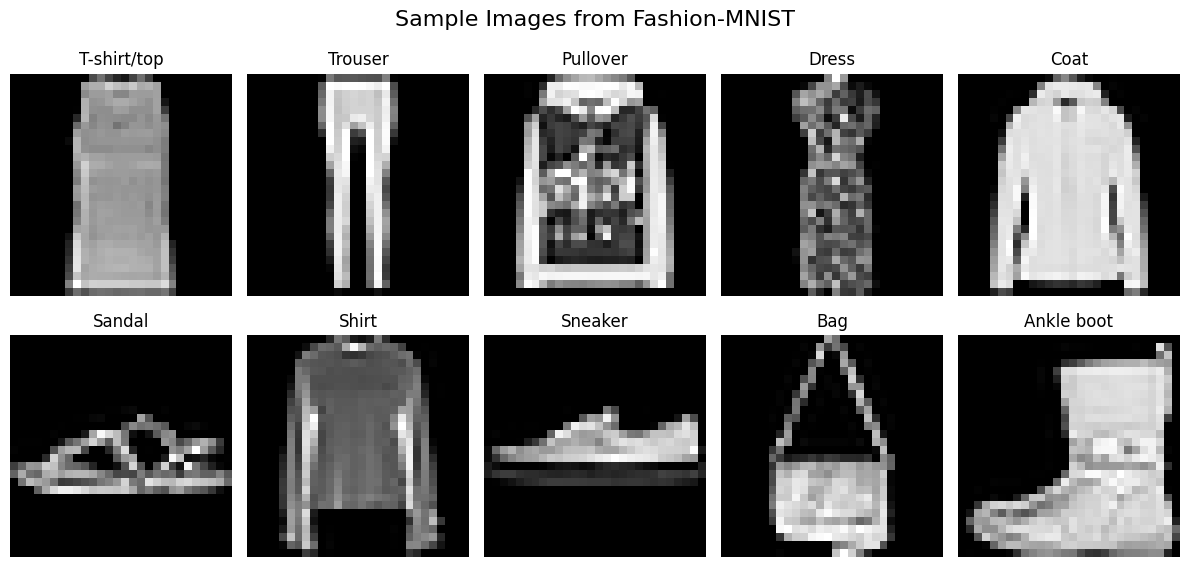


Part B: PCA Implementation
Applying PCA...
PCA computation time: 0.19 seconds


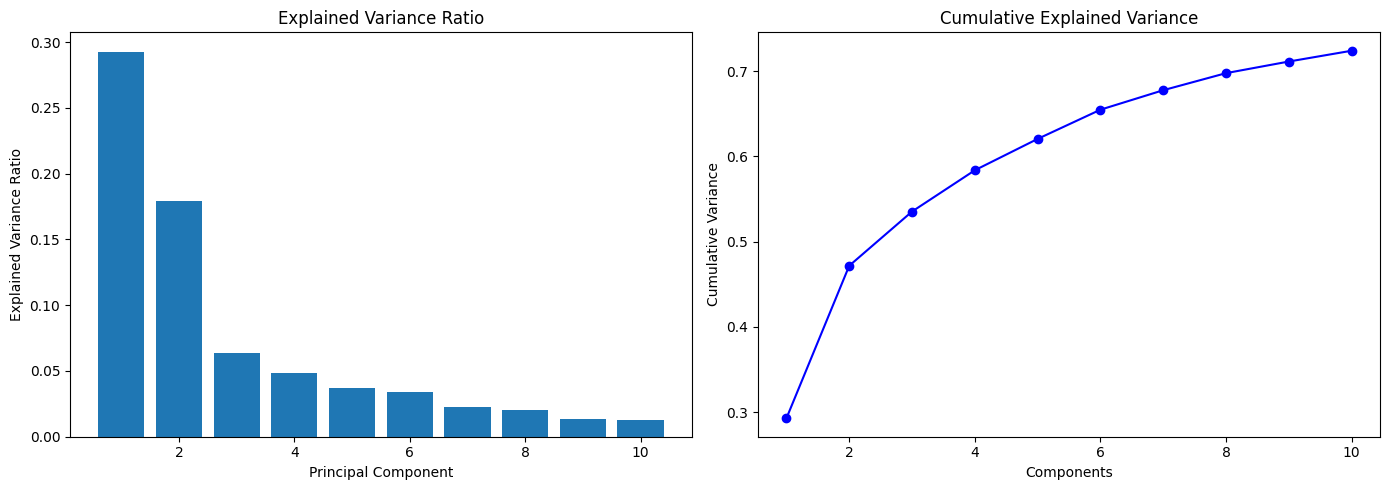

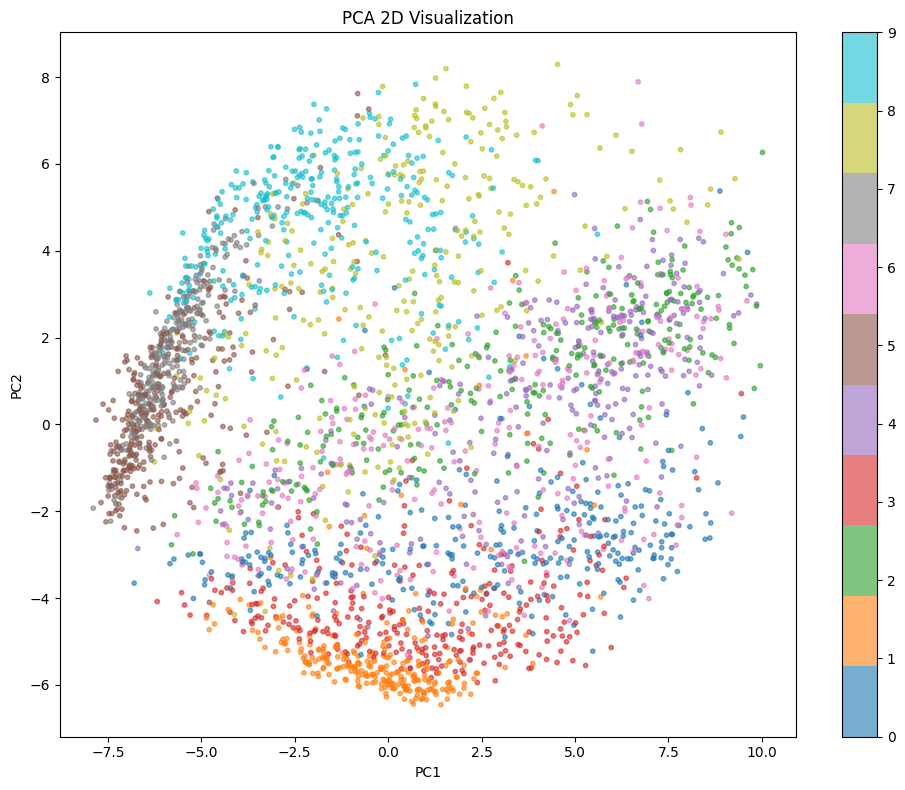


Part C: t-SNE Implementation
Running t-SNE (perplexity=5)...
Time: 29.58 sec
Running t-SNE (perplexity=30)...
Time: 31.75 sec
Running t-SNE (perplexity=50)...
Time: 37.89 sec


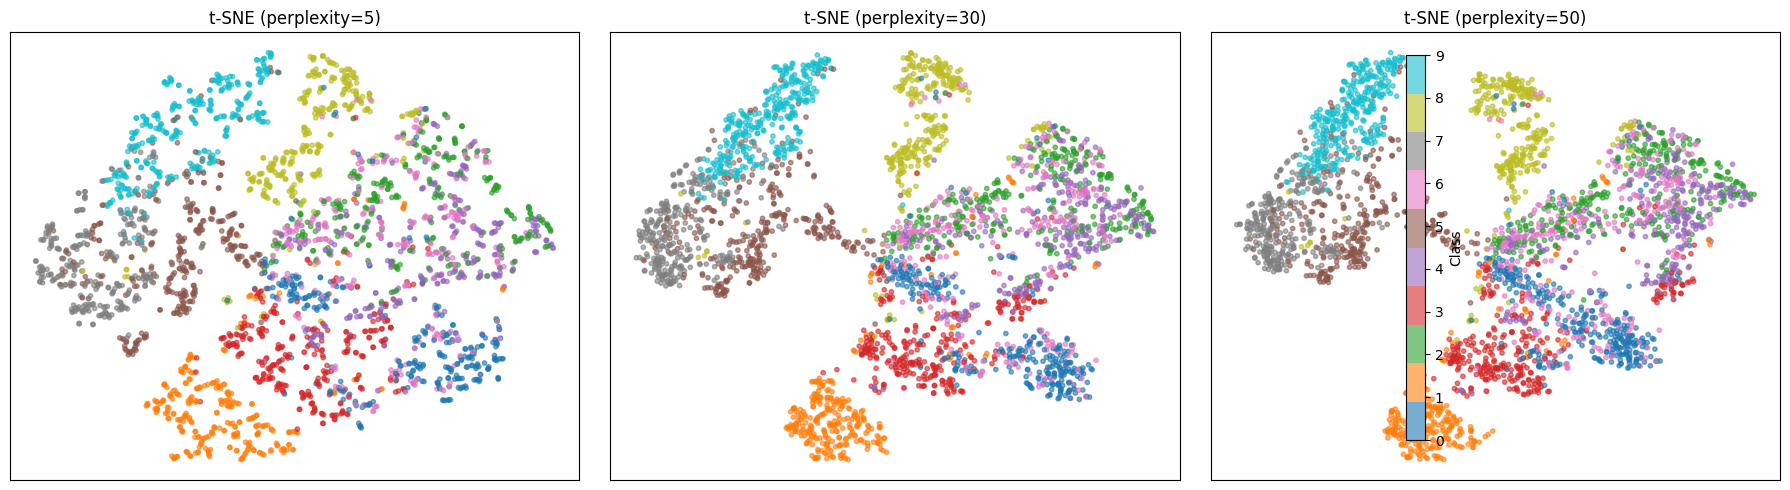


Part D: Comparison and Analysis

--- Computation Time ---
PCA: 0.19 sec
t-SNE (perp=5): 29.58 sec
t-SNE (perp=30): 31.75 sec
t-SNE (perp=50): 37.89 sec


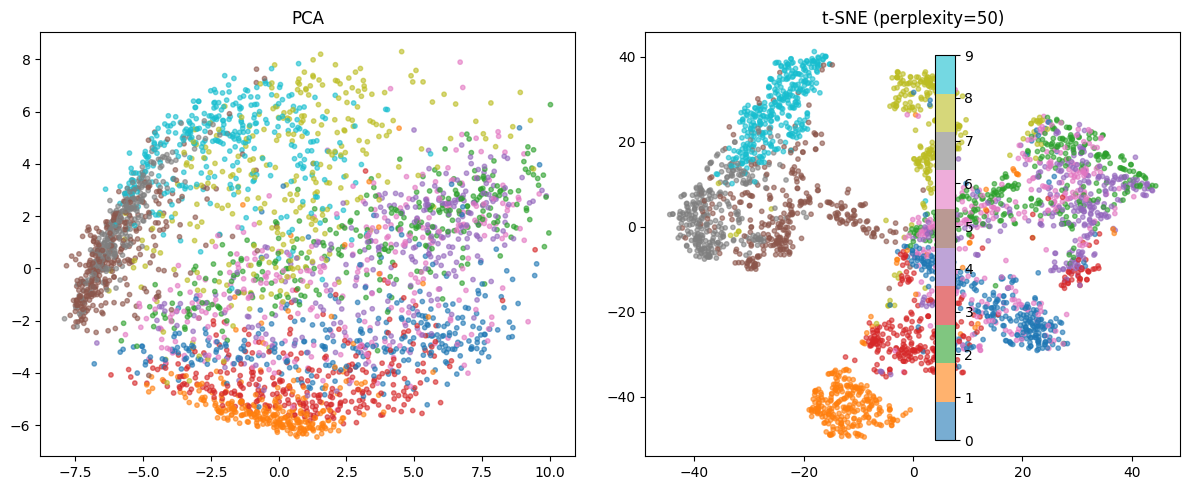


--- Cluster Separation Analysis ---

Quantitative Comparison:
PCA silhouette score: -0.036
t-SNE (perp=5) silhouette score: 0.123
t-SNE (perp=30) silhouette score: 0.167
t-SNE (perp=50) silhouette score: 0.177


In [1]:
#IN-LAB
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import time
import warnings

warnings.filterwarnings('ignore')

print("=" * 50)
print("Part A: Data Loading and Preparation")
print("=" * 50)

print("Loading Fashion-MNIST dataset...")
fashion_mnist = fetch_openml('Fashion-MNIST', version=1, as_frame=False)

X, y = fashion_mnist.data, fashion_mnist.target.astype(int)

n_samples = 3000
np.random.seed(42)
indices = np.random.choice(X.shape[0], n_samples, replace=False)
X = X[indices]
y = y[indices]

print(f"Dataset shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution: {np.bincount(y)}")

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("\nNormalizing pixel values...")
X_normalized = X / 255.0


fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for i in range(10):
    idx = np.where(y == i)[0][0]
    axes[i].imshow(X[idx].reshape(28, 28), cmap='gray')
    axes[i].set_title(class_names[i])
    axes[i].axis('off')

plt.suptitle("Sample Images from Fashion-MNIST", fontsize=16)
plt.tight_layout()
plt.savefig("fashion_mnist_samples.png", dpi=150)
plt.show()


print("\n" + "=" * 50)
print("Part B: PCA Implementation")
print("=" * 50)

print("Applying PCA...")
start_time = time.time()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_normalized)

pca_time = time.time() - start_time
print(f"PCA computation time: {pca_time:.2f} seconds")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pca_full = PCA(n_components=10)
pca_full.fit(X_normalized)

axes[0].bar(range(1, 11), pca_full.explained_variance_ratio_[:10])
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Explained Variance Ratio")

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, 11), cumulative_variance[:10], 'bo-')
axes[1].set_xlabel("Components")
axes[1].set_ylabel("Cumulative Variance")
axes[1].set_title("Cumulative Explained Variance")

plt.tight_layout()
plt.savefig("pca_variance.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=10, alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Visualization")
plt.colorbar(scatter)
plt.tight_layout()
plt.savefig("pca_visualization.png", dpi=150)
plt.show()

print("\n" + "=" * 50)
print("Part C: t-SNE Implementation")
print("=" * 50)

perplexities = [5, 30, 50]

tsne_results = {}
tsne_times = {}

fig, axes = plt.subplots(1, len(perplexities), figsize=(18, 5))

for i, perplexity in enumerate(perplexities):
    print(f"Running t-SNE (perplexity={perplexity})...")
    start_time = time.time()

    tsne = TSNE(n_components=2, perplexity=perplexity,
                random_state=42, max_iter=1000)

    X_tsne = tsne.fit_transform(X_normalized)
    tsne_time = time.time() - start_time

    tsne_results[perplexity] = X_tsne
    tsne_times[perplexity] = tsne_time

    print(f"Time: {tsne_time:.2f} sec")

    scatter = axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1],
                              c=y, cmap='tab10', s=10, alpha=0.6)
    axes[i].set_title(f"t-SNE (perplexity={perplexity})")
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.colorbar(scatter, ax=axes, label='Class')
plt.tight_layout()
plt.savefig("tsne_comparison.png", dpi=150)
plt.show()


print("\n" + "=" * 50)
print("Part D: Comparison and Analysis")
print("=" * 50)

print("\n--- Computation Time ---")
print(f"PCA: {pca_time:.2f} sec")
for p, t in tsne_times.items():
    print(f"t-SNE (perp={p}): {t:.2f} sec")

best_perplexity = 50

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=y, cmap='tab10', s=10, alpha=0.6)
axes[0].set_title("PCA")

scatter2 = axes[1].scatter(tsne_results[best_perplexity][:, 0],
                           tsne_results[best_perplexity][:, 1],
                           c=y, cmap='tab10', s=10, alpha=0.6)
axes[1].set_title(f"t-SNE (perplexity={best_perplexity})")

plt.colorbar(scatter1, ax=axes)
plt.tight_layout()
plt.savefig("pca_vs_tsne.png", dpi=150)
plt.show()

print("\n--- Cluster Separation Analysis ---")

def analyze_clusters(X_embedded, y_true, method_name):
    try:
        if X_embedded.shape[0] > 10000:
            idx = np.random.choice(X_embedded.shape[0], 10000, replace=False)
            score = silhouette_score(X_embedded[idx], y_true[idx])
        else:
            score = silhouette_score(X_embedded, y_true)

        print(f"{method_name} silhouette score: {score:.3f}")
    except Exception as e:
        print(f"{method_name} failed: {e}")

print("\nQuantitative Comparison:")
analyze_clusters(X_pca, y, "PCA")

for p in perplexities:
    analyze_clusters(tsne_results[p], y, f"t-SNE (perp={p})")